# Figure 4: Bulk Reconstruction

Figure 4 studies approximate entanglement-wedge reconstruction by adding an unmeasured probe to bulk sites and measuring its mutual information with selected boundary regions.

This figure includes:

* (a) a small connected boundary region
* (b) a large connected boundary region
* (c) two disconnected boundary regions with an expected disconnected wedge
* (d) two disconnected boundary regions with an expected connected wedge


## Import Dependencies


In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import loadconfig as loco

from matplotlib import gridspec
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.transforms import Bbox
from tqdm import tqdm

from figure_helpers.cartography import (
    draw_rt_surface,
    draw_rt_surface_discontinuous,
    invert_lightness,
)
from graph2grav.cartography.reconstruction import (
    add_bulk_node,
    compute_bulk_entropies,
    get_post_measurement_covariance,
)
from graph2grav.figure_hashing import save_figure_with_hash
from graph2grav.graphs.standard import crosslinked_tree, make_tree_periodic, tree_node_depth

config = loco.reload()


## Set Parameters and Build Base Graph

Define the graph and boundary regions used in the final four-panel reconstruction figure.


In [2]:
%config InlineBackend.print_figure_kwargs = {'bbox_inches': 'tight'}
%matplotlib inline

MERA_DEPTH = 6
COUPLING_TIME = 1.0
PRESQUEEZE = 1.0
BULK_COUPLING = 1.0
EXPORT_OUTPUTS = True
FIGURE_PATH = "figures/figure_4_undecorated_wedge_reconsruction.pdf"

G_tree = crosslinked_tree(depth=MERA_DEPTH)
G = make_tree_periodic(G_tree, remove_nodes=False)

boundary_nodes = sorted([n for n, d in G.nodes(data=True) if d.get("is_boundary", False)])
ancilla_nodes = sorted([n for n, d in G.nodes(data=True) if d.get("is_ancilla", False)])
n_boundary = len(boundary_nodes)

region_configs = [
    (16, "Contiguous: 16 nodes"),
    (40, "Contiguous: 40 nodes"),
    ([(0, 6), (32, 52)], "Discontinuous: 6+20 nodes"),
    ([(0, 20), (32, 52)], "Discontinuous: 20+20 nodes"),
]

print(f"MERA graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Boundary nodes: {len(boundary_nodes)}")
print(f"Ancilla probe positions: {len(ancilla_nodes)}")


MERA graph: 127 nodes, 251 edges
Boundary nodes: 64
Ancilla probe positions: 63


## Compute Reconstruction Data

For each plotted boundary region, attach a probe to every bulk/ancilla site and compute the mutual information between the probe and the selected boundary region.


In [3]:
def selected_nodes_from_region_spec(region_spec):
    if isinstance(region_spec, int):
        return boundary_nodes[:region_spec]

    selected_boundary = []
    for start, end in region_spec:
        selected_boundary.extend(boundary_nodes[start:end])
    return selected_boundary


def compute_entropies_for_region(selected_boundary_nodes, verbose=True):
    entropies_by_position = {}
    iterator = tqdm(ancilla_nodes, desc="Computing MI") if verbose else ancilla_nodes

    for bulk_pos in iterator:
        graph_ext, bulk_id = add_bulk_node(G, bulk_pos, coupling=BULK_COUPLING)
        cov_post, kept_indices, bulk_idx_kept = get_post_measurement_covariance(
            graph_ext,
            bulk_id,
            use_weighted=False,
            couplingtime=COUPLING_TIME,
            global_presqueeze=PRESQUEEZE,
            bulk_presqueeze=PRESQUEEZE,
            boundary_presqueeze=PRESQUEEZE,
        )

        node_to_idx = {node: idx for idx, node in enumerate(kept_indices)}
        region_indices = [node_to_idx[n] for n in selected_boundary_nodes if n in node_to_idx]
        entropies_by_position[bulk_pos] = compute_bulk_entropies(
            cov_post,
            region_indices,
            bulk_idx_kept,
            len(kept_indices),
        )

    return entropies_by_position


print("Computing entropies for each region configuration...")
entropy_results_by_config = {}

for config_idx, (region_spec, title) in enumerate(region_configs):
    print(f"\n{title}:")
    selected_boundary = selected_nodes_from_region_spec(region_spec)
    entropy_results_by_config[config_idx] = compute_entropies_for_region(
        selected_boundary,
        verbose=True,
    )

print("\nEntropy computation complete!")
print(f"Computed entropies for {len(region_configs)} region configurations")
print(f"Each configuration has {len(ancilla_nodes)} bulk positions")


Computing entropies for each region configuration...

Contiguous: 16 nodes:


Computing MI: 100%|██████████| 63/63 [00:03<00:00, 16.28it/s]



Contiguous: 40 nodes:


Computing MI: 100%|██████████| 63/63 [00:03<00:00, 17.46it/s]



Discontinuous: 6+20 nodes:


Computing MI: 100%|██████████| 63/63 [00:03<00:00, 17.61it/s]



Discontinuous: 20+20 nodes:


Computing MI: 100%|██████████| 63/63 [00:03<00:00, 17.68it/s]


Entropy computation complete!
Computed entropies for 4 region configurations
Each configuration has 63 bulk positions


## Make Figure

Draw the MERA geometry, selected boundary regions, RT curves, and bulk-node color map for normalized mutual information.


Saved figure to figures/figure_4_undecorated_wedge_reconsruction.pdf. Hash info updated in figures/.hashes.json; history in figures/.hash_history.json. file_hash=8d04fccc7acc99f4, data_hash=3b6b33d0a7894f80, size=32312 bytes.


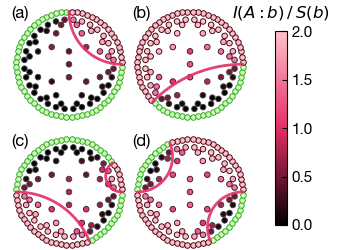

In [4]:
bbox = Bbox.from_bounds(0.0, 0.0, 3.375, 2.5)
%config InlineBackend.print_figure_kwargs = {'bbox_inches': bbox}
%matplotlib inline

pink_black = LinearSegmentedColormap.from_list(
    "pink_black",
    ["black", "#e52d67ff", "pink"],
)
pink_black.set_under("black")
pink_black.set_over("pink")

rt_color = config["graph"]["nodes"]["selected_boundary"].get("ryu_takayanagi", {}).get("color", "cyan")
rt_linewidth = 2.0
hyperbolic_spacing = 0.5
pos = {}

for node in G.nodes():
    if G.nodes[node].get("is_boundary"):
        boundary_pos = G.nodes[node].get("position_in_boundary", 0)
        angular_position = 2 * np.pi * boundary_pos / len(boundary_nodes) + np.pi / len(boundary_nodes)
        radius = 1.0
    else:
        node_depth = tree_node_depth(node)
        nodes_at_depth = sorted([
            n for n in G.nodes()
            if tree_node_depth(n) == node_depth and not G.nodes[n].get("is_boundary")
        ])
        if node in nodes_at_depth:
            node_idx = nodes_at_depth.index(node)
            angular_position = 2 * np.pi * node_idx / len(nodes_at_depth) + np.pi / len(nodes_at_depth)
        else:
            angular_position = 0
        radius = np.tanh(hyperbolic_spacing * node_depth / 2)

    pos[node] = np.array([radius * np.cos(angular_position), radius * np.sin(angular_position)])

angular_spacing = 2 * np.pi / len(boundary_nodes)
angular_offset = angular_spacing / 2

fig = plt.figure(figsize=(bbox.width, bbox.height))
spec = gridspec.GridSpec(
    2,
    4,
    hspace=0.1,
    wspace=0,
    width_ratios=[1, 1, 0.2, 0.1],
    left=0.025,
    bottom=0,
    top=0.975,
    right=0.85,
)
axes = [fig.add_subplot(spec[0, 0]), fig.add_subplot(spec[0, 1]),
        fig.add_subplot(spec[1, 0]), fig.add_subplot(spec[1, 1])]

cgs = spec[:, 3].subgridspec(3, 1, height_ratios=[0.05, 0.90, 0.05])
cbar_ax = fig.add_subplot(cgs[1, 0])

node_scale = 1 / 5
boundary_node_size = config["graph"]["nodes"]["boundary"]["outer"]["size"] * node_scale
ancilla_node_size = config["graph"]["nodes"]["ancilla"]["outer"]["size"] * node_scale
selected_boundary_node_size = config["graph"]["nodes"]["selected_boundary"]["outer"]["size"] * node_scale

boundary_linewidth = np.sqrt(boundary_node_size) * 0.165
ancilla_linewidth = np.sqrt(ancilla_node_size) * 0.165
selected_linewidth = np.sqrt(selected_boundary_node_size) * 0.165

cmap = pink_black
norm = Normalize(vmin=0, vmax=2)

for config_idx, (region_spec, title) in enumerate(region_configs):
    ax = axes[config_idx]
    selected_boundary = selected_nodes_from_region_spec(region_spec)
    unselected_boundary = [n for n in boundary_nodes if n not in selected_boundary]

    if isinstance(region_spec, int):
        draw_rt_surface(
            ax,
            pos,
            boundary_nodes,
            selected_boundary,
            color=rt_color,
            linewidth=rt_linewidth,
            alpha=0.9,
            zorder=10,
        )
    else:
        regions = []
        for start, end in region_spec:
            first_node = boundary_nodes[start]
            last_node = boundary_nodes[end - 1]
            p1 = pos[first_node]
            p2 = pos[last_node]
            theta1 = np.arctan2(p1[1], p1[0]) - angular_offset
            theta2 = np.arctan2(p2[1], p2[0]) + angular_offset
            regions.append((theta1, theta2))
        draw_rt_surface_discontinuous(
            ax,
            boundary_nodes,
            regions,
            color=rt_color,
            linewidth=rt_linewidth,
            alpha=0.9,
            zorder=10,
        )

    if unselected_boundary:
        nx.draw_networkx_nodes(
            G,
            pos,
            nodelist=unselected_boundary,
            node_color=config["graph"]["nodes"]["boundary"]["inner"]["color"],
            node_size=boundary_node_size,
            edgecolors=config["graph"]["nodes"]["boundary"]["outer"]["color"],
            linewidths=boundary_linewidth,
            ax=ax,
        )

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=selected_boundary,
        node_color=config["graph"]["nodes"]["selected_boundary"]["inner"]["color"],
        node_size=selected_boundary_node_size,
        edgecolors=invert_lightness(cmap(1.0)),
        linewidths=selected_linewidth,
        ax=ax,
    )

    normalized_MI_by_position = {}
    for n, ent in entropy_results_by_config[config_idx].items():
        S_b = ent["S_b"]
        MI = ent["MI_R_b"]
        normalized_MI_by_position[n] = MI / S_b if S_b > 1e-10 else 0.0

    probed_nodes = [n for n in ancilla_nodes if n in normalized_MI_by_position]
    if probed_nodes:
        node_colors = [cmap(norm(normalized_MI_by_position.get(n, 0.0))) for n in probed_nodes]
        nx.draw_networkx_nodes(
            G,
            pos,
            nodelist=probed_nodes,
            node_color=node_colors,
            node_size=ancilla_node_size,
            edgecolors=[invert_lightness(c) for c in node_colors],
            linewidths=ancilla_linewidth,
            ax=ax,
        )

for ax in axes:
    ax.set_aspect("equal")
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    circle = plt.Circle((0, 0), 1, color="black", fill=False, linewidth=1)
    ax.add_artist(circle)
    ax.set_axis_off()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, cax=cbar_ax, orientation="vertical")
cbar.ax.set_title(r"$I(A:b)\,/\,S(b)$", fontsize=12, pad=10)

for n, ax in enumerate(axes):
    letter = chr(ord("a") + n)
    ax.text(
        0,
        1,
        f"({letter})",
        transform=ax.transAxes,
        fontsize=config["subfigure-label"]["font"]["size"],
        fontweight="bold",
        va="top",
        ha="left",
    )

if EXPORT_OUTPUTS:
    save_figure_with_hash(fig, FIGURE_PATH, bbox_inches=bbox)
